<a href="https://colab.research.google.com/github/2303A51434/natural-language-processing/blob/main/paper_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (19200, 5)
Epoch 0 | Loss: 0.6951 | Acc: 0.4980
Epoch 1 | Loss: 0.6920 | Acc: 0.5050
Epoch 2 | Loss: 0.6892 | Acc: 0.5258
Epoch 3 | Loss: 0.6864 | Acc: 0.5967
Epoch 4 | Loss: 0.6837 | Acc: 0.6554
Epoch 5 | Loss: 0.6810 | Acc: 0.6847
Epoch 6 | Loss: 0.6781 | Acc: 0.6989
Epoch 7 | Loss: 0.6752 | Acc: 0.6994
Epoch 8 | Loss: 0.6720 | Acc: 0.6993
Epoch 9 | Loss: 0.6686 | Acc: 0.6991
Epoch 10 | Loss: 0.6648 | Acc: 0.6968
Epoch 11 | Loss: 0.6606 | Acc: 0.6965
Epoch 12 | Loss: 0.6560 | Acc: 0.6959
Epoch 13 | Loss: 0.6508 | Acc: 0.6961
Epoch 14 | Loss: 0.6451 | Acc: 0.6957
Epoch 15 | Loss: 0.6388 | Acc: 0.6952
Epoch 16 | Loss: 0.6319 | Acc: 0.6957
Epoch 17 | Loss: 0.6244 | Acc: 0.6958
Epoch 18 | Loss: 0.6163 | Acc: 0.6961
Epoch 19 | Loss: 0.6077 | Acc: 0.6964
Epoch 20 | Loss: 0.5988 | Acc: 0.6957
Epoch 21 | Loss: 0.5901 | Acc: 0.6959
Epoch 22 | Loss: 0.5819 | Acc: 0.6951
Epoch 23 | Loss: 0.5751 | Acc: 0.6933
Epoch 24 | Loss: 0.5703 | Acc: 0.6911
Epoch 25 | Loss: 0.5684 | Acc: 0.6

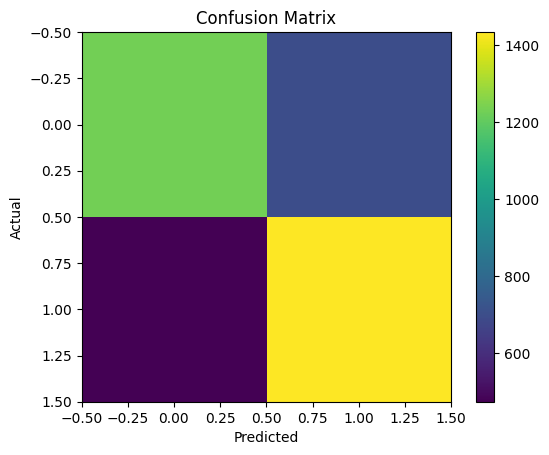

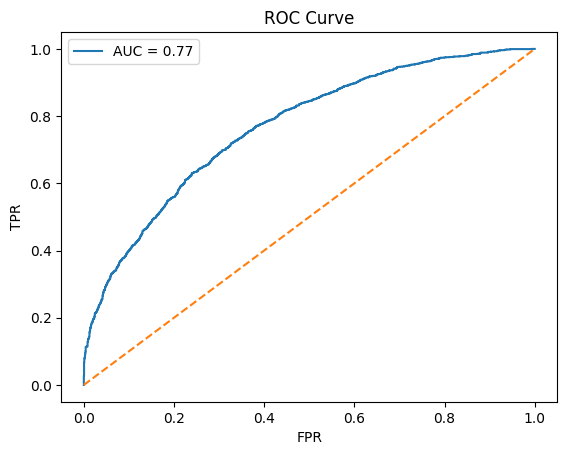

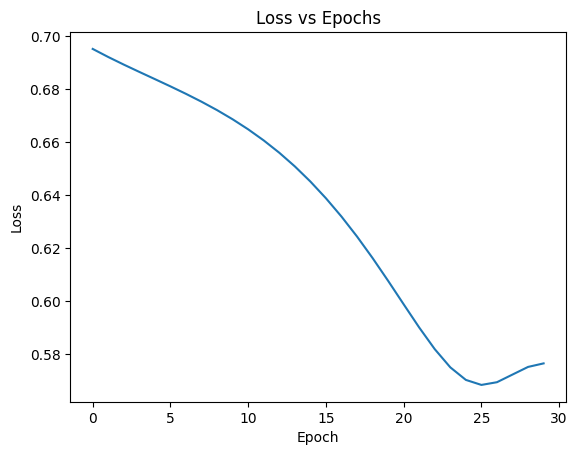

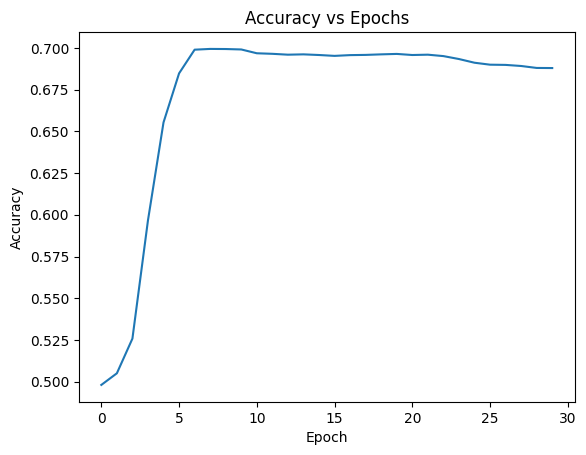

In [ ]:
# ==============================
# 1 Install Libraries
# ==============================
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install scikit-learn

# ==============================
# 2 Imports
# ==============================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt

# ==============================
# 3 Load Dataset
# ==============================
file1 = "/content/S15S1.csv"
file2 = "/content/S15S2.csv"

data1 = pd.read_csv(file1)
data2 = pd.read_csv(file2)

data = pd.concat([data1, data2], axis=0)

print("Dataset Shape:", data.shape)

# ==============================
# 4 Preprocessing
# ==============================
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Binarize y for classification (e.g., using median as threshold)
y = (y > np.median(y)).astype(int)

# Normalize
X = (X - X.mean()) / X.std()

# ==============================
# 5 Create Temporal Sequences
# ==============================
def create_sequences(X, y, seq_len=10):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X, y, seq_len=10)

# Convert to tensors
X_seq = torch.tensor(X_seq, dtype=torch.float)
y_seq = torch.tensor(y_seq, dtype=torch.long)

# ==============================
# 6 Train Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

# ==============================
# 7 Graph Structure (EEG Electrodes)
# ==============================
num_nodes = X.shape[1]

edges = []
for i in range(num_nodes - 1):
    edges.append([i, i+1])
    edges.append([i+1, i])

edge_index = torch.tensor(edges).t().contiguous()

# ==============================
# 8 Model: GCN + LSTM (Improved)
# ==============================
class STGNN(nn.Module):

    def __init__(self, num_nodes):
        super(STGNN, self).__init__()

        self.gcn1 = GCNConv(1, 32)
        self.gcn2 = GCNConv(32, 64)

        self.lstm = nn.LSTM(64, 64, batch_first=True)

        self.fc = nn.Linear(64, 2)

    def forward(self, x, edge_index):

        batch_size, seq_len, num_nodes = x.shape

        gcn_outputs = []

        for t in range(seq_len):

            xt = x[:, t, :]  # (batch, nodes)
            xt = xt.unsqueeze(-1)  # (batch, nodes, 1)

            g_out = []

            for b in range(batch_size):
                out = self.gcn1(xt[b], edge_index)
                out = torch.relu(out)

                out = self.gcn2(out, edge_index)
                out = torch.relu(out)

                out = torch.mean(out, dim=0)  # pooling
                g_out.append(out)

            g_out = torch.stack(g_out)
            gcn_outputs.append(g_out)

        gcn_outputs = torch.stack(gcn_outputs, dim=1)

        lstm_out, _ = self.lstm(gcn_outputs)

        out = self.fc(lstm_out[:, -1, :])

        return out

# ==============================
# 9 Initialize
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = STGNN(num_nodes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Move data
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# ==============================
# 10 Training
# ==============================
epochs = 30

loss_list = []
acc_list = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    output = model(X_train, edge_index.to(device))

    loss = criterion(output, y_train)

    loss.backward()
    optimizer.step()

    _, pred = torch.max(output, 1)

    acc = (pred == y_train).sum().item() / len(y_train)

    loss_list.append(loss.item())
    acc_list.append(acc)

    print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

# ==============================
# 11 Evaluation
# ==============================
model.eval()

with torch.no_grad():

    output = model(X_test, edge_index.to(device))

    probs = torch.softmax(output, dim=1)[:, 1].cpu().numpy()

    _, pred = torch.max(output, 1)

    pred = pred.cpu().numpy()
    y_true = y_test.cpu().numpy()

# ==============================
# 12 Confusion Matrix
# ==============================
cm = confusion_matrix(y_true, pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# ==============================
# 13 ROC Curve
# ==============================
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# ==============================
# 14 Loss vs Epochs
# ==============================
plt.figure()
plt.plot(loss_list)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ==============================
# 15 Accuracy vs Epochs
# ==============================
plt.figure()
plt.plot(acc_list)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()